In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sort-sort-new/sort.py
/kaggle/input/sort-sort-new/LICENSE
/kaggle/input/sort-sort-new/.gitignore
/kaggle/input/sort-sort-new/README.md
/kaggle/input/sort-sort-new/requirements.txt


In [2]:
data = {
    'Time': [0.0, 0.0, 1/30, 1/30],  # Seconds
    'Frame_ID': [1, 1, 2, 2],
    'Vehicle_ID': [101, 102, 101, 102],
    'X_central': [100, 300, 105, 295],
    'Y_central': [150, 150, 155, 155],
    'X1_boundary': [90, 290, 95, 285],
    'Y1_boundary': [140, 140, 145, 145],
    'X2_boundary': [110, 310, 115, 305],
    'Y2_boundary': [140, 140, 145, 145],
    'X3_boundary': [110, 310, 115, 305],
    'Y3_boundary': [160, 160, 165, 165],
    'X4_boundary': [90, 290, 95, 285],
    'Y4_boundary': [160, 160, 165, 165]
}

df = pd.DataFrame(data)

In [3]:
!pip install shapely matplotlib  # Install required packages

In [4]:
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt

# Define conflict zone coordinates (X,Y)
lane_width = 20  # Example value
conflict_zone = Polygon([
    (80, 100),   # Bottom-left
    (120, 100),  # Bottom-right
    (120, 200),  # Top-right
    (80, 200)    # Top-left
])

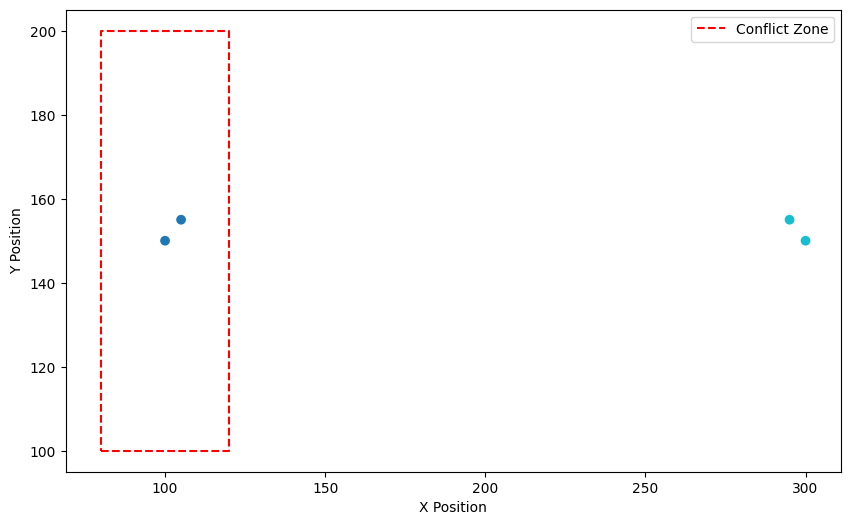

In [5]:
# Visualize the zone
x, y = conflict_zone.exterior.xy
plt.figure(figsize=(10,6))
plt.plot(x, y, 'r--', label='Conflict Zone')
plt.scatter(df['X_central'], df['Y_central'], c=df['Vehicle_ID'], cmap='tab10')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.show()

In [6]:
def in_conflict_zone(row, zone):
    vehicle_center = Point(row['X_central'], row['Y_central'])
    return zone.contains(vehicle_center)

# Apply to dataframe
df['In_Conflict_Zone'] = df.apply(in_conflict_zone, zone=conflict_zone, axis=1)

# Filter conflict zone entries
conflict_entries = df[df['In_Conflict_Zone']]
print(conflict_entries[['Time', 'Vehicle_ID', 'X_central', 'Y_central']])

       Time  Vehicle_ID  X_central  Y_central
0  0.000000         101        100        150
2  0.033333         101        105        155


In [7]:
df

,Time,Frame_ID,Vehicle_ID,X_central,Y_central,X1_boundary,Y1_boundary,X2_boundary,Y2_boundary,X3_boundary,Y3_boundary,X4_boundary,Y4_boundary,In_Conflict_Zone
0,0.000000,1,101,100,150,90,140,110,140,110,160,90,160,True
1,0.000000,1,102,300,150,290,140,310,140,310,160,290,160,False
2,0.033333,2,101,105,155,95,145,115,145,115,165,95,165,True
3,0.033333,2,102,295,155,285,145,305,145,305,165,285,165,False


In [8]:
!pip install filterpy lap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.7 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110458 sha256=efaf41de118a01635408c61a48383eb4a504489ad78eea7b720f70feea566ff3
  Stored in directory: /root/.cache/pip/wheels/12/dc/3c/e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy


In [9]:
!git clone https://github.com/abewley/sort.git

Cloning into 'sort'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 208 (delta 2), reused 1 (delta 1), pack-reused 203 (from 2)
Receiving objects: 100% (208/208), 1.20 MiB | 18.69 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [10]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if 'sort' in file.lower():
            print(os.path.join(root, file))

/kaggle/input/sort-sort-new/sort.py


In [11]:
!ls /kaggle/input/sort-sort-new

LICENSE  README.md  requirements.txt  sort.py


In [12]:
!cp /kaggle/input/sort-sort-new/sort.py /kaggle/working/sort_module.py

In [13]:
import sys
sys.path.append('/kaggle/working')

In [14]:
from sort_module import Sort

# Initialize SORT tracker
mot_tracker = Sort(max_age=3, min_hits=1)

# Process frames sequentially
tracked_data = []

for frame_id in df['Frame_ID'].unique():
    frame_data = df[df['Frame_ID'] == frame_id]
    
    # Format detections as [x1,y1,x2,y2,score]
    detections = frame_data[['X1_boundary', 'Y1_boundary', 
                            'X3_boundary', 'Y3_boundary']].values
    scores = np.ones((len(detections), 1))  # Confidence score (dummy)
    detections = np.hstack([detections, scores])
    
    # Update tracker
    trackers = mot_tracker.update(detections)
    
    # Store tracked data: [x1,y1,x2,y2,track_id]
    for d in trackers:
        tracked_data.append([frame_id] + d.tolist())

# Convert to DataFrame
tracked_df = pd.DataFrame(
    tracked_data,
    columns=['Frame_ID', 'X1_boundary', 'Y1_boundary', 'X3_boundary', 'Y3_boundary', 'track_id']
)

In [15]:
tracked_df

,Frame_ID,X1_boundary,Y1_boundary,X3_boundary,Y3_boundary,track_id
0,1,290.000000,140.000000,310.000000,160.000000,2.0
1,1,90.000000,140.000000,110.000000,160.000000,1.0
2,2,285.000499,144.999501,305.000499,164.999501,2.0
3,2,94.999501,144.999501,114.999501,164.999501,1.0


In [16]:
tracked_df = tracked_df.round({
    'X1_boundary': 0,
    'Y1_boundary': 0,
    'X3_boundary': 0,
    'Y3_boundary': 0
})

In [17]:
# Merge with original coordinates
merged_df = pd.merge(df, tracked_df, 
                    on=['Frame_ID', 'X1_boundary', 'Y1_boundary', 'X3_boundary', 'Y3_boundary'],
                    how='left')

In [18]:
merged_df

,Time,Frame_ID,Vehicle_ID,X_central,Y_central,X1_boundary,Y1_boundary,X2_boundary,Y2_boundary,X3_boundary,Y3_boundary,X4_boundary,Y4_boundary,In_Conflict_Zone,track_id
0,0.000000,1,101,100,150,90,140,110,140,110,160,90,160,True,1.0
1,0.000000,1,102,300,150,290,140,310,140,310,160,290,160,False,2.0
2,0.033333,2,101,105,155,95,145,115,145,115,165,95,165,True,1.0
3,0.033333,2,102,295,155,285,145,305,145,305,165,285,165,False,2.0


In [19]:
conflict_log = []

for track_id in merged_df['track_id'].dropna().unique():
    track = merged_df[merged_df['track_id'] == track_id].sort_values('Time')
    in_zone = False
    entry_time = None

    for _, row in track.iterrows():
        if row['In_Conflict_Zone'] and not in_zone:
            entry_time = row['Time']
            in_zone = True
        elif not row['In_Conflict_Zone'] and in_zone:
            exit_time = row['Time']
            conflict_log.append({
                'track_id': track_id,
                'entry_time': entry_time,
                'exit_time': exit_time,
                'duration': exit_time - entry_time
            })
            in_zone = False

In [20]:
conflict_log

[]

In [21]:
if conflict_log:
    conflict_df = pd.DataFrame(conflict_log).sort_values('exit_time')

    for i in range(1, len(conflict_df)):
        prev = conflict_df.iloc[i-1]
        curr = conflict_df.iloc[i]
        
        pet = curr['entry_time'] - prev['exit_time']
        if pet > 0:
            pet_data.append({
                'leading_vehicle': prev['track_id'],
                'following_vehicle': curr['track_id'],
                'pet': pet
            })

    pet_df = pd.DataFrame(pet_data)
else:
    print("⚠️ No conflicts to calculate PET from.")
    pet_df = pd.DataFrame()

⚠️ No conflicts to calculate PET from.


In [22]:
import matplotlib.pyplot as plt
import numpy as np

if not pet_df.empty:
    # Plot PET distribution
    plt.hist(pet_df['pet'], bins=np.arange(0, 5, 0.2))
    plt.xlabel('PET (seconds)')
    plt.ylabel('Frequency')
    plt.title('Post-Encroachment Time Distribution')
    plt.show()

    # Print high-risk conflicts
    print(pet_df[pet_df['pet'] < 1.5].sort_values('pet'))
else:
    print("⚠️ No PET data available to visualize.")

⚠️ No PET data available to visualize.
